# import stuff

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# read in data

In [6]:
coma = pd.read_csv('coma.csv')

# compute cluster centre & mean redshift

In [7]:
#calculate cluster centre
mean_ra = np.mean(coma['RA'])
mean_dec = np.mean(coma['Dec'])

#calculate mean cluster redshift
mean_z = np.mean(coma['Redshift (z)'])

# report results & compare to literature

In [10]:
print(f"Calculated cluster center:")
print(f"  RA = {mean_ra:.4f}°")
print(f"  Dec = {mean_dec:.4f}°")
print(f"  Redshift z = {mean_z:.6f}")

#published values (from NASA/IPAC - https://ned.ipac.caltech.edu/byname?objname=Coma+Cluster&hconst=67.8&omegam=0.308&omegav=0.692&wmap=4&corr_z=1)
pub_ra = 194.953000
pub_dec = 27.981000
pub_z = 0.023997

#calculate differences
delta_ra = abs(mean_ra - pub_ra)
delta_dec = abs(mean_dec - pub_dec)
delta_z = abs(mean_z - pub_z)

print(f"\nDifferences from published values:")
print(f"  ΔRA = {delta_ra:.4f}° = {delta_ra*3600:.2f} arcsec")
print(f"  ΔDec = {delta_dec:.4f}° = {delta_dec*3600:.2f} arcsec")
print(f"  Δz = {delta_z:.6f}")

Calculated cluster center:
  RA = 194.9665°
  Dec = 27.9739°
  Redshift z = 0.023295

Differences from published values:
  ΔRA = 0.0135° = 48.53 arcsec
  ΔDec = 0.0071° = 25.61 arcsec
  Δz = 0.000702


# redshift histogram

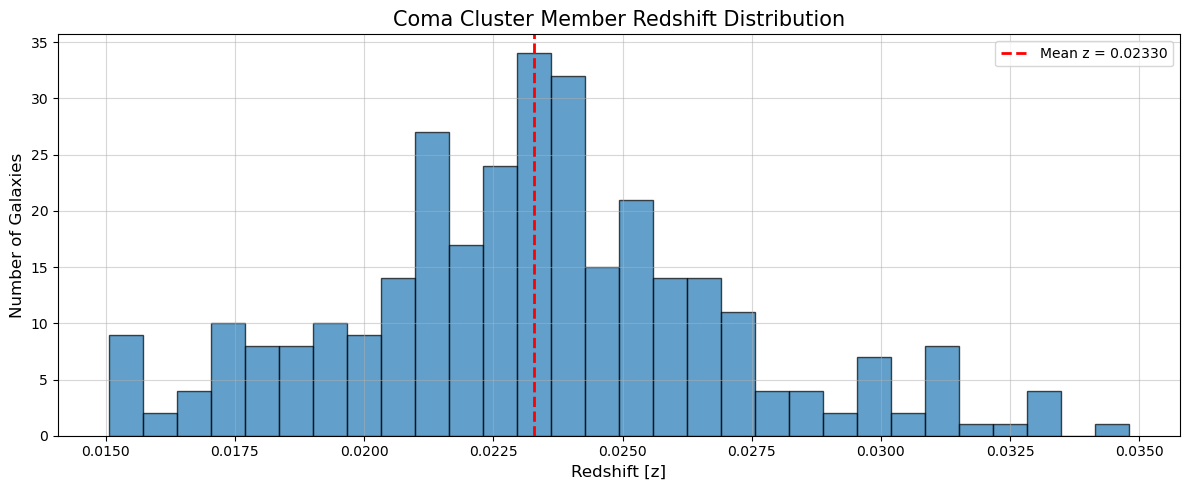

In [19]:
plt.figure(figsize = (12, 5))

plt.title('Coma Cluster Member Redshift Distribution', fontsize = 15)

#histogram
plt.hist(coma['Redshift (z)'], bins = 30, edgecolor = 'black', alpha = 0.7) #want nbr of bins to be ~10% of sample size (hence 30)

#axis labels
plt.xlabel('Redshift [z]', fontsize = 12)
plt.ylabel('Number of Galaxies', fontsize = 12)

#show mean redshift
plt.axvline(mean_z, color = 'red', linestyle = '--', linewidth = 2, label = f'Mean z = {mean_z:.5f}')

plt.legend()
plt.grid(True, alpha = 0.5)

plt.tight_layout()

#save
plt.savefig('zHist.png')

# calculate velocity dispersion

In [23]:
#speed of light
c = 299792.458 # in km/s

#calculate velocities from redshifts
vels = coma['Redshift (z)'] * c

#calculate velocity dispersion as stdev of velocities
sigma_v = vels.std()

print(f"\nVelocity Dispersion:")
print(f"  σ_v = {sigma_v:.2f} km/s")

#published value for Coma is ~ 1,000 km/s (from this paper: https://iopscience.iop.org/article/10.1086/313274, see ACO 1656)
pub_sigma = 1000
print(f"\nPublished value: ~{pub_sigma} km/s")
print(f"Difference: {sigma_v - pub_sigma:.2f} km/s")


Velocity Dispersion:
  σ_v = 1130.58 km/s

Published value: ~1000 km/s
Difference: 130.58 km/s


# plot radial density profile

In [28]:
#calculated cluster centre from before
centre_ra = mean_ra
centre_dec = mean_dec

#get angular radius for each galaxy (in degrees)
coma['radius_deg'] = np.sqrt(((coma['RA'] - centre_ra) * np.cos(np.radians(centre_dec)))**2 + (coma['Dec'] - centre_dec)**2)

#convert to arcseconds
coma['radius_arcsec'] = coma['radius_deg']*3600

print(f"Radial range: {coma['radius_arcsec'].min():.1f} to {coma['radius_arcsec'].max():.1f} arcsec")

Radial range: 28.9 to 640.0 arcsec


In [58]:
#create radial bins
bin_width = 60
max_rad = np.max(coma['radius_arcsec'])

bins = np.arange(0, max_rad + bin_width, bin_width)

#count galaxies in each bin
counts, bin_edges = np.histogram(coma['radius_arcsec'], bins = bins)

#find bin_centers
bin_centers = (bin_edges[:-1] + bin_edges[1:])/2

#get area of each annulus - area = pi*(r_outer^2 - r_inner^2)
inner_radii = bin_edges[:-1]
outer_radii = bin_edges[1:]

areas = np.pi*(outer_radii**2 - inner_radii**2) #in arcsec^2

#calculate surface density
surf_density = counts/areas

print(f"\nNumber of radial bins: {len(bin_centers)}")


Number of radial bins: 11


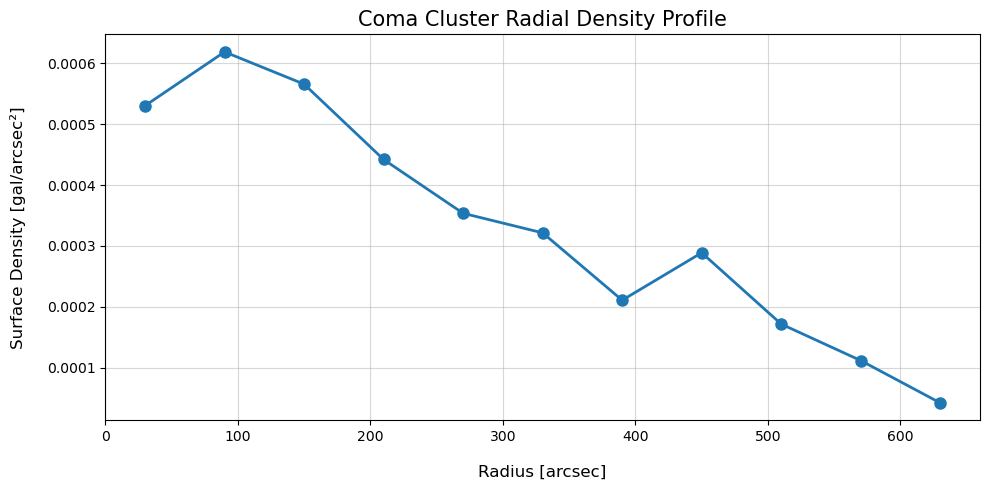

In [62]:
plt.figure(figsize = (10, 5))

plt.title('Coma Cluster Radial Density Profile', fontsize = 15)

#plot the density profile
plt.plot(bin_centers, surf_density, 'o-', markersize = 8, linewidth = 2)

#axis labels
plt.xlabel('Radius [arcsec]', fontsize = 12, labelpad = 15)
plt.ylabel('Surface Density [gal/arcsec²]', fontsize = 12, labelpad = 15)

plt.grid(True, alpha = 0.5)

plt.tight_layout()

plt.savefig('density_profile.png')